<a href="https://colab.research.google.com/github/MehrdadJalali-AI/Statistics-and-Machine-Learning/blob/main/InClass/Chapter_3_Time_Series_Full_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Analytics 1 – Statistics and Machine Learning  
## Chapter 3: Time Series Analysis (Hands-on Notebook)

**Instructor:** Prof. Dr. Mehrdad Jalali  

This notebook follows the lecture slides step-by-step and is designed for **learning and understanding**.

**Goals of this notebook**
- Understand what time series data is
- Decompose a time series into **trend, seasonality, residual**
- Apply **moving average & exponential smoothing**
- Build and compare **AR, ARMA, ARIMA, SARIMA, Prophet**
- Visualize everything clearly (very important)
- Follow a correct **forecasting workflow**

All code blocks are preceded by **clear explanations** of:
- the method
- the class/function used
- the parameters



## 1. Import Required Libraries

We use standard Python libraries for time series analysis.

**Libraries**
- `pandas`: data handling
- `numpy`: numerical operations
- `matplotlib`: visualization
- `statsmodels`: classical time series models
- `prophet`: modern forecasting with trend + seasonality


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

plt.rcParams['figure.figsize'] = (12, 5)



## 2. Dataset: AirPassengers (Classic Time Series)

This dataset contains **monthly airline passenger numbers (1949–1960)**.

Why this dataset?
- Clear **trend**
- Strong **seasonality**
- Ideal for teaching decomposition and forecasting


In [2]:

# Load dataset directly
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
data = pd.read_csv(url)

data['Month'] = pd.to_datetime(data['Month'])
data.set_index('Month', inplace=True)

data.head()


,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121



### Plot the Original Time Series


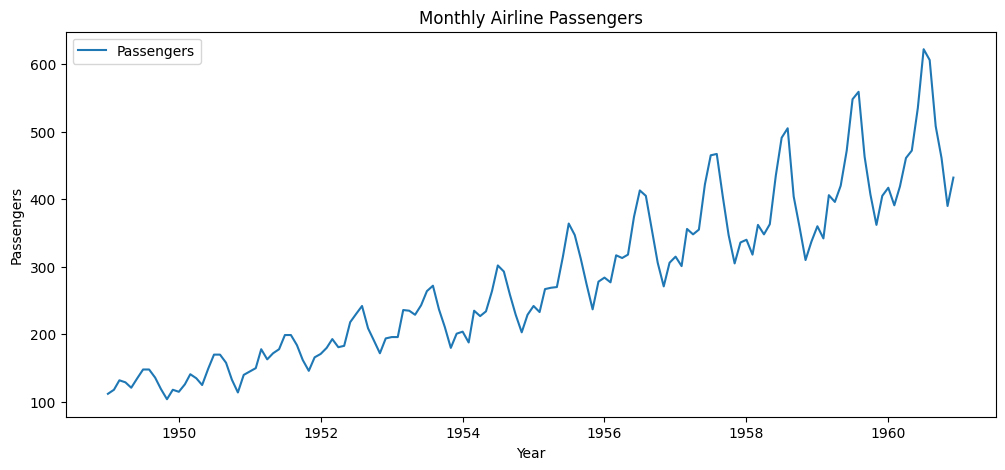

In [3]:

plt.plot(data, label="Passengers")
plt.title("Monthly Airline Passengers")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.legend()
plt.show()



## 3. Time Series Decomposition

**Goal:** Split the time series into:
- Trend
- Seasonality
- Residual (Noise)

We use:
`seasonal_decompose()` from `statsmodels`

**Important parameter**
- `model='additive'`: assumes components add together
- `period=12`: monthly seasonality


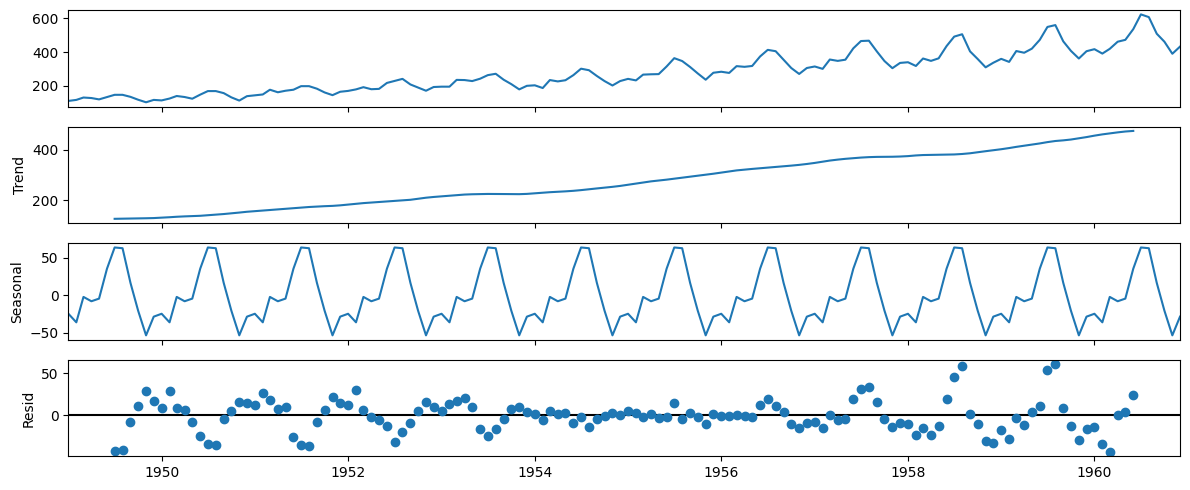

In [4]:

decomposition = seasonal_decompose(data, model='additive', period=12)

decomposition.plot()
plt.show()



## 4. Trend Estimation – Moving Average

**Moving Average**
- Smooths short-term fluctuations
- Highlights long-term trend

Parameter:
- `window=12`: average over one year


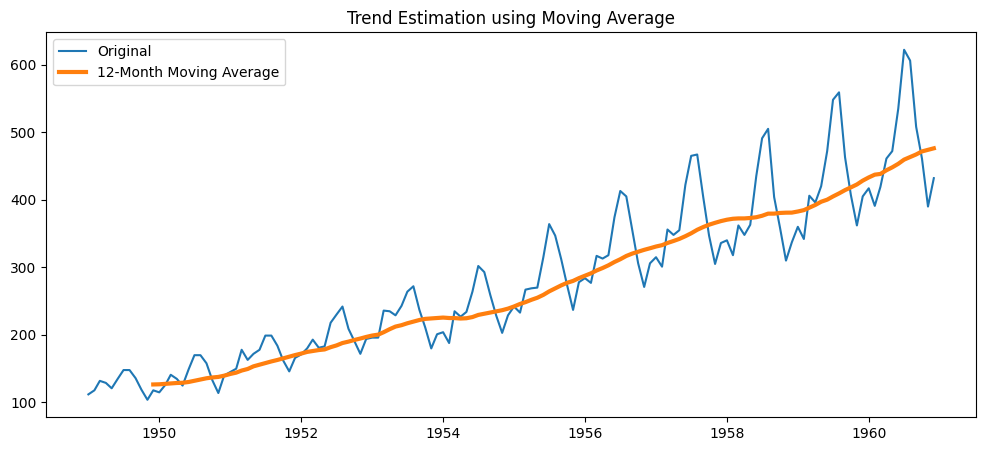

In [5]:

data['Moving_Avg_12'] = data['Passengers'].rolling(window=12).mean()

plt.plot(data['Passengers'], label='Original')
plt.plot(data['Moving_Avg_12'], label='12-Month Moving Average', linewidth=3)
plt.legend()
plt.title("Trend Estimation using Moving Average")
plt.show()



## 5. Autoregressive (AR) Model

**Concept**
- Predict future values using past values only

**Class**
`AutoReg()`

**Key Parameters**
- `lags`: how many past steps are used


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


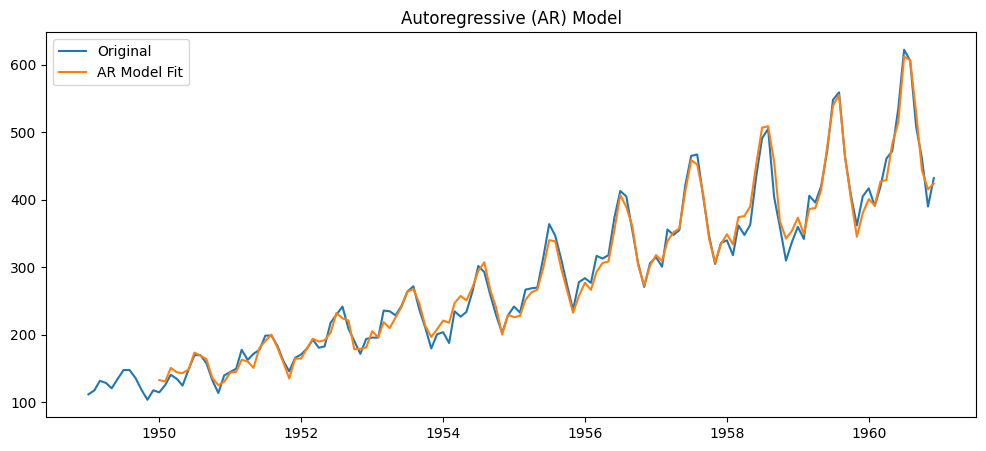

In [6]:

ar_model = AutoReg(data['Passengers'], lags=12).fit()

data['AR_Pred'] = ar_model.fittedvalues

plt.plot(data['Passengers'], label='Original')
plt.plot(data['AR_Pred'], label='AR Model Fit')
plt.legend()
plt.title("Autoregressive (AR) Model")
plt.show()



## 6. ARIMA Model

**ARIMA(p, d, q)**  
- p: autoregressive order  
- d: differencing (trend removal)  
- q: moving average order  

Used for **non-stationary** data with trend


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


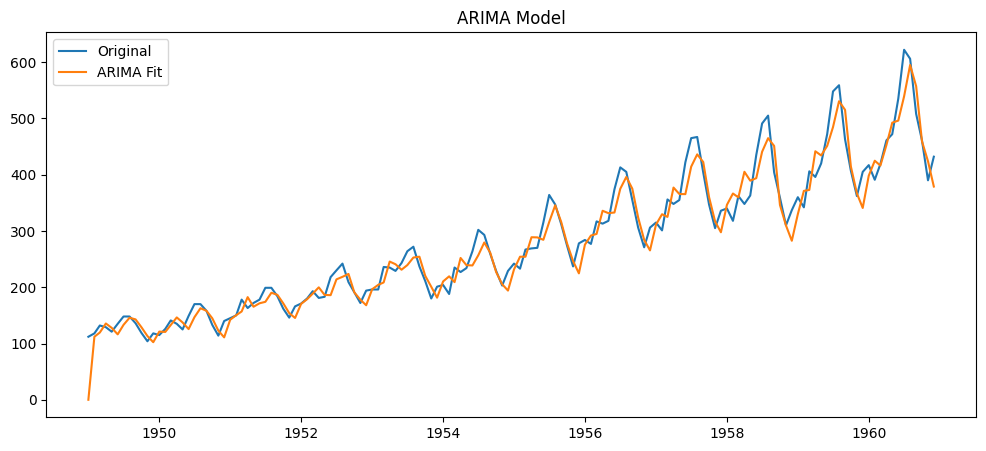

In [7]:

arima_model = ARIMA(data['Passengers'], order=(2,1,2)).fit()

data['ARIMA_Fit'] = arima_model.fittedvalues

plt.plot(data['Passengers'], label='Original')
plt.plot(data['ARIMA_Fit'], label='ARIMA Fit')
plt.legend()
plt.title("ARIMA Model")
plt.show()



## 7. SARIMA – Seasonal ARIMA

SARIMA adds **seasonality** to ARIMA.

**SARIMAX class**
- `order=(p,d,q)`
- `seasonal_order=(P,D,Q,s)`


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


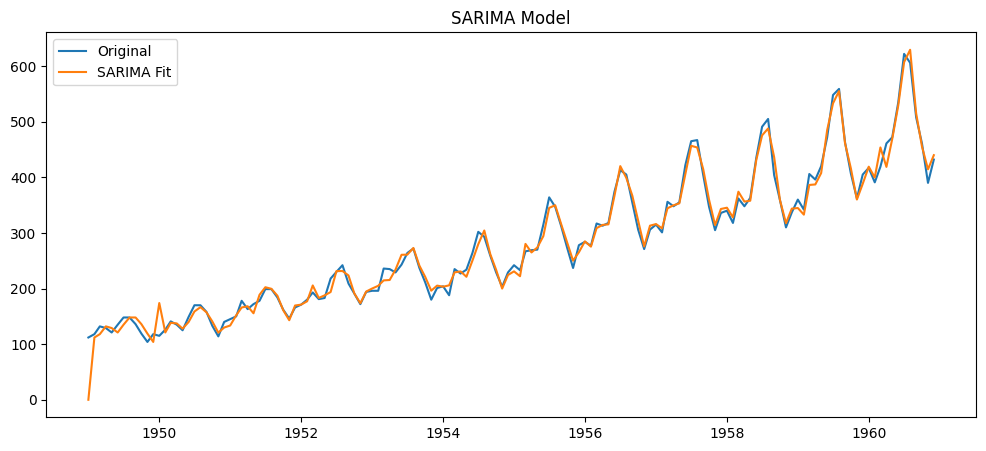

In [8]:

sarima_model = SARIMAX(
    data['Passengers'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
).fit()

data['SARIMA_Fit'] = sarima_model.fittedvalues

plt.plot(data['Passengers'], label='Original')
plt.plot(data['SARIMA_Fit'], label='SARIMA Fit')
plt.legend()
plt.title("SARIMA Model")
plt.show()



## 8. Prophet Model

**Prophet**
- Additive trend + seasonality
- Very strong for business time series

**Columns required**
- `ds`: date
- `y`: value


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


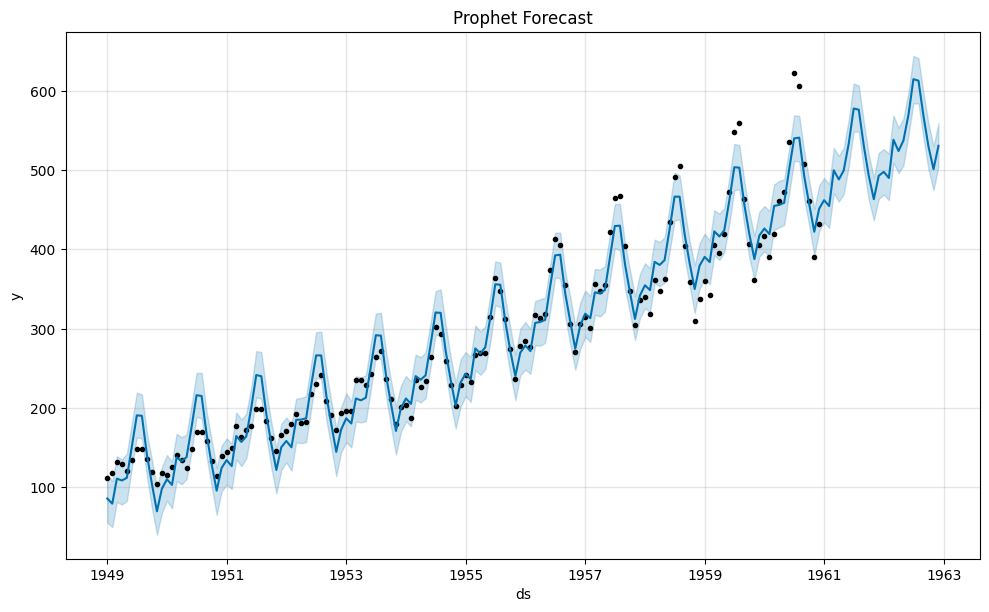

In [10]:
from prophet import Prophet

prophet_df = data.reset_index()[['Month', 'Passengers']]
prophet_df.columns = ['ds', 'y']

model = Prophet()
model.fit(prophet_df)

future = model.make_future_dataframe(periods=24, freq='M')
forecast = model.predict(future)

model.plot(forecast)
plt.title("Prophet Forecast")
plt.show()


## 9. Key Takeaways

- **Visualization is essential** in time series analysis
- Decomposition helps understand structure
- AR / ARIMA → good baselines
- SARIMA → strong seasonal forecasting
- Prophet → practical and robust

This notebook is designed to directly match the **lecture slides** and support student exercises.
